# Analýza přežití doby do odchodu studentské kohorty

## Shrnutí pro vedení

**Kontext.** Oddělení institucionálního výzkumu na čtyřleté vysoké škole chce pochopit, *kdy*, nikoli jen *zda*, studenti odcházejí. Kohorta studentů prvního zápisu je sledována semestr po semestru od zápisu; někteří promují, někteří odejdou a několik je stále zapsaných, když se pozorovací okno uzavře. Protože výsledek u stále zapsaných studentů je neznámý (cenzurovaný zprava) a protože promoce odebírá studenta z rizikové skupiny, aniž by šlo o odchod, běžná regrese typu prospěl/neprospěl zahazuje informaci o načasování a zkresluje jakýkoli odhad, který cenzurování ignoruje. Správným nástrojem je **analýza doby do události (analýza přežití)**, kde sledovanou událostí je **odchod** a čas se měří v absolvovaných akademických semestrech.

**Obchodní otázka.** Odděluje **studijní stav v prvním semestru** (příznak včasného varování) trajektorie načasování odchodu v kohortě a které charakteristiky studenta řídí riziko odchodu po úpravě? Odpovědi napájejí systém včasného varování: studenti, jejichž odhadované riziko odchodu je vysoké, by měli v prvních semestrech dostat poradenskou podporu, kdy je intervence nejlevnější a nejúčinnější.

**Přístup.** Simulujeme kohortu 100 studentů uvnitř notebooku (žádná externí data) a poté procházíme standardní pracovní postup analýzy přežití:

1. **PROC MEANS** profiluje prediktory napříč třemi pozorovanými výsledky (Absolvoval / Odešel / stále Zapsán) k potvrzení, že simulovaný signál se chová smysluplně.
2. **PROC FREQ** křížově tabeluje studijní stav v prvním semestru proti výsledku s chí-kvadrát testem asociace.
3. **PROC UNIVARIATE** vykazuje robustní percentily doby do odchodu podle stavu.
4. **PROC LIFETEST** odhaduje Kaplan-Meierovy křivky odchodu stratifikované podle stavu a provádí **log-rank** a **Wilcoxonovy** testy rovnosti.
5. **PROC PHREG** fituje vícerozměrný **Coxův model proporcionálních rizik** pro riziko odchodu, s referenčně kódovaným efektem `CLASS`, Efronovým ošetřením shod a konfidenčními intervaly rizikových mezí.

**Co data ukazují.** Ze 100 simulovaných studentů **49 odešlo, 49 promovalo a 2 zůstali zapsaní** ke stropu 12 semestrů. Studenti označení pro **studijní varování** v prvním semestru (GPA prvního semestru pod 2.5) odcházejí mnohem rychleji než studenti v dobrém stavu: medián doby do odchodu **3.8 semestru vs 8.7 semestru**, což je oddělení, které log-rank test potvrzuje (chí-kvadrát = 10.73, *p* = 0.0011). Coxův model identifikuje GPA prvního semestru (poměr rizik 0.21 na bod GPA, *p* < 0.0001), středoškolské GPA (HR 0.45, *p* = 0.027) a status první generace (HR 2.03, *p* = 0.031) jako významné upravené faktory odchodu, zatímco status Pellova grantu není významný, jakmile je GPA zohledněno (HR 0.95, *p* = 0.85).

> *Všechny hodnoty jsou ilustrativní a generované ze syntetických dat; nejde o skutečné studentské záznamy. Toto prostředí běží bez licence, takže je kohorta dimenzována na 100 studentů.*

## Zdroje dat

Všechna data jsou **syntetická**, generovaná uvnitř prvního kroku DATA pomocí `CALL STREAMINIT(20260611)` a funkce `RAND`. Žádné externí soubory ani přístup k síti. Jeden řádek na simulovaného studenta.

**Datová sada `zapisy`** (100 řádků, jeden řádek na studenta)

| Proměnná | Typ | Popis | Generující rozdělení |
|----------|------|-------------|--------------------------|
| `id_studenta` | Num | Jedinečný klíč studenta | posloupnost 1–100 |
| `prvni_generace` / `prvni_generace_popis` | Num / Char | Příznak první generace (0/1) a popisek | Bernoulli, ~42% |
| `pell` | Num | Příznak Pellova grantu (finanční potřeba) (0/1) | Bernoulli, ~42% |
| `obor` | Char | STEM / Ekonomie / Humanitní | kategoriální (~42% / 32% / 26%) |
| `ss_prumer` | Num | Středoškolské GPA (1.8–4.0) | Normal(3.00, 0.42), ořezané |
| `prumer_1sem` | Num | GPA prvního semestru na VŠ (0–4.0) | f(ss_prumer, obor) + normální šum |
| `akademicky_stav` | Char | Studijní stav v prvním semestru | `prumer_1sem < 2.5` → Akademická výstraha, jinak Good akademicky_stav |
| `cas_semestry` | Num | Absolvované semestry do události nebo cenzurování | konkurenční Weibullovy losy; omezeno na 12 |
| `odesel` | Num | Indikátor události odchodu (1 = odešel, 0 = cenzurováno) | odvozeno |
| `vysledek` | Char | Absolvoval / Odešel / Zapsán | odvozeno z konkurenčních losů |

Latentní lineární prediktor na logaritmické škále propojuje **míru odchodu** každého studenta s GPA prvního semestru, středoškolským GPA, statusem první generace a finanční potřebou, takže prediktory nesou skutečný, ale zašuměný signál. Odchod a promoce jsou losovány jako **konkurenční** latentní časy (Weibull); ten, který nastane dříve uvnitř okna 12 semestrů, se stává pozorovaným výsledkem, a studenti, kteří dosáhnou semestru 12 bez jednoho z nich, jsou cenzurováni zprava. Pro modely přežití je **událostí odchod** (`odesel = 1`); promoce i probíhající zápis jsou obě chápány jako cenzurování (`odesel = 0`).

## 1. Simulace studentské kohorty

První buňka sestavuje syntetickou kohortu 100 studentů. Latentní lineární prediktor na logaritmické škále váže míru odchodu každého studenta na GPA prvního semestru, středoškolské GPA, status první generace a status Pell. Odchod a promoce jsou generovány jako **konkurenční** latentní časy (Weibullovy losy); ten, který nastane dříve uvnitř pozorovacího okna 12 semestrů, se stává pozorovaným výsledkem, a studenti, kteří dosáhnou semestru 12 bez odchodu či promoce, jsou cenzurováni zprava. GPA prvního semestru pod 2.5 označuje studenta pro **studijní varování** — signál včasného varování, který testujeme v kroku přežití. Náhodné losy používají `CALL STREAMINIT` pro reprodukovatelnost a funkci `RAND` napříč rovnoměrným, normálním a Weibullovým rozdělením. Pevné dolní meze a ořezání udržují každou hodnotu věrohodnou (GPA v 0–4.0).

In [1]:
data zapisy;
    CALL streaminit(20260611);
    DÉLKA akademicky_stav $32 prvni_generace_popis $32 obor $16 vysledek $16;
    OPAKUJ id_studenta = 1 TO 100;
        /* Příznaky první generace a finanční potřeby */
        prvni_generace = (rand("uniform") < 0.42);
        KDYŽ prvni_generace PAK prvni_generace_popis = "První generace";
        JINAK                   prvni_generace_popis = "Pokračující generace";
        pell = (rand("uniform") < 0.42);

        /* Studijní obor */
        v = rand("uniform");
        KDYŽ      v < 0.42 PAK obor = "STEM";
        JINAK KDYŽ v < 0.74 PAK obor = "Ekonomie";
        JINAK                  obor = "Humanitní";

        /* Akademická příprava a výkon v prvním semestru */
        ss_prumer = round(MIN(4.0, MAX(1.8, rand("normal", 3.00, 0.42))), 0.01);
        prumer_1sem = round(MIN(4.0, MAX(0.0,
                     0.55*ss_prumer + 1.05 + 0.12*(obor="STEM")
                     + rand("normal", 0, 0.42))), 0.01);

        /* Příznak včasného varování: GPA prvního semestru pod 2.5 = akademická výstraha */
        KDYŽ prumer_1sem < 2.5 PAK akademicky_stav = "Akademická výstraha";
        JINAK                     akademicky_stav = "Dobrý stav";

        /* Latentní riziko odchodu na logaritmické škále: nižší GPA, první generace
           a status Pell zvyšují míru odchodu. */
        eta = -1.05
             - 1.45*(prumer_1sem - 2.8)
             - 0.55*(ss_prumer - 3.0)
             + 1.05*prvni_generace
             + 0.45*pell;
        mira_odchodu = EXP(eta);

        /* Konkurenční latentní časy (semestry): odchod vs promoce */
        cas_odchodu = rand("weibull", 1.2, 7.0) / MAX(0.30, mira_odchodu);
        cas_promoce = rand("weibull", 2.0, 7.5)
                 * EXP(-0.18*(prumer_1sem - 2.8));

        /* 12semestrové administrativní okno cenzurování */
        cenzura_v = 12;
        KDYŽ cas_odchodu <= cas_promoce AND cas_odchodu <= cenzura_v PAK OPAKUJ;
            vysledek = "Odešel";     odesel = 1; cas_semestry = cas_odchodu;
        KONEC;
        JINAK KDYŽ cas_promoce < cas_odchodu AND cas_promoce <= cenzura_v PAK OPAKUJ;
            vysledek = "Absolvoval"; odesel = 0; cas_semestry = cas_promoce;
        KONEC;
        JINAK OPAKUJ;
            vysledek = "Zapsán";     odesel = 0; cas_semestry = cenzura_v;
        KONEC;
        cas_semestry = round(cas_semestry, 0.1);
        ŠTÍTEK prvni_generace       = "První generace (0/1)"
              prvni_generace_popis = "První generace"
              pell                 = "Pellův grant"
              obor                 = "Studijní obor"
              ss_prumer            = "Průměr SŠ"
              prumer_1sem          = "Průměr 1. semestr"
              akademicky_stav      = "Akademický stav"
              cas_semestry         = "Semestry do události"
              odesel               = "Odchod (událost)"
              vysledek             = "Výsledek";
        VÝSTUP;
    KONEC;
    PONECHAT id_studenta prvni_generace prvni_generace_popis pell obor ss_prumer
         prumer_1sem akademicky_stav cas_semestry odesel vysledek;
SPUSTIT;



NOTE: DATA zapisy


NOTE: Wrote zapisy (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Profilování prediktorů podle pozorovaného výsledku

Před modelováním potvrzujeme, že se simulované prediktory pohybují očekávanými směry. **PROC MEANS** vykazuje počet, průměr, rozptyl a rozpětí každého číselného prediktoru v rámci tří pozorovaných výsledků.

Kohorta se dělí na **49 Absolvoval / 49 Odešel / 2 stále Zapsán**. Absolventi nesou vyšší GPA prvního semestru (průměr **2.94** vs **2.54** u studentů, kteří odešli) a vyšší středoškolské GPA (**3.10** vs **2.90**) — přesně ten gradient akademické připravenosti, který analýza očekává. Dva stále zapsaní studenti sedí přesně na stropě cenzurování 12 semestrů u `cas_semestry` (průměr 12.00, směrodatná odchylka 0), tj. cenzurování zprava, které musí analýza úbytku respektovat. Mezi studenty, kteří odešli, přichází událost brzy: průměr **3.31 semestru**, s rozpětím od 0.1 do 8.9.

In [2]:
PROCEDURA PRŮMĚRY data=zapisy n mean std MIN MAX maxdec=2;
    TŘÍDA vysledek;
    PROMĚNNÁ ss_prumer prumer_1sem cas_semestry;
    ŠTÍTEK vysledek="Výsledek" ss_prumer="Průměr SŠ"
          prumer_1sem="Průměr 1. semestr" cas_semestry="Semestry do události";
SPUSTIT;


                                                  The MEANS Procedure

                                       Analysis Variable : ss_prumer Průměr SŠ

        Výsledek            N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Absolvoval             49           3.10           0.46           1.97           4.00
        Odešel                 49           2.90           0.45           2.01           3.89
        Zapsán                  2           3.10           0.17           2.98           3.22
        -------------------------------------------------------------------------------------

                                  Analysis Variable : prumer_1sem Průměr 1. semestr

        Výsledek            N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        Abs


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 3. Sleduje příznak včasného varování výsledek?

Systém včasného varování označí pro **studijní varování** každého studenta, jehož GPA prvního semestru klesne pod 2.5. **PROC FREQ** křížově tabeluje tento příznak proti pozorovanému výsledku a provádí chí-kvadrát test asociace. Potlačujeme řádková, sloupcová a celková procenta (`NOROW NOCOL NOPERCENT`), aby tabulka ukazovala hrubé počty, a přidáváme jednorozměrné četnosti `akademicky_stav` a statusu první generace pro složení kohorty.

Křížová tabulka je výmluvná: z **29** studentů označených pro studijní varování jich **21 odešlo** a jen 8 promovalo; ze **71** v dobrém stavu jich **41 promovalo** a 28 odešlo. Asociace je významná (chí-kvadrát = 9.21, df = 2, *p* = 0.0100; Cramérovo V = 0.30). Všimněte si **varování vypsaného spolu s ní**: se 100 studenty a tenkým sloupcem „Zapsán" o dvou absolventech má třetina buněk tabulky očekávané počty pod 5, takže chí-kvadrát *p*-hodnota je zde křehká. Právě tato křehkost je důvodem, proč testy přežití v dalších sekcích — které používají úplnou informaci o načasování namísto tabulky 3×2 — jsou důvěryhodnějším testem efektu stavu.

                                                   The FREQ Procedure

Table of Akademický stav by Výsledek

Akademický stav       |Absolvoval |    Odešel |    Zapsán |      Total
----------------------+-----------+-----------+-----------+-----------
Akademická výstraha   |         8 |        21 |         0 |         29
----------------------+-----------+-----------+-----------+-----------
Dobrý stav            |        41 |        28 |         2 |         71
----------------------+-----------+-----------+-----------+-----------
Total                 |        49 |        49 |         2 |        100

Statistics for Table of Akademický stav by Výsledek

Statistic                                DF  Value         Prob
--------------------------------------------------------------
Chi-Square                                2 9.2089       0.0100
Likelihood Ratio Chi-Square               2 9.8909       0.0071

Cramer's V                           0.3035
Contingency Coefficient              0.2


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_akademicky_stav_vysledek.spec.json
NOTE: ODS plot written: freq_akademicky_stav.spec.json
NOTE: ODS plot written: freq_prvni_generace_popis.spec.json
NOTE: PROC FREQ statement used.


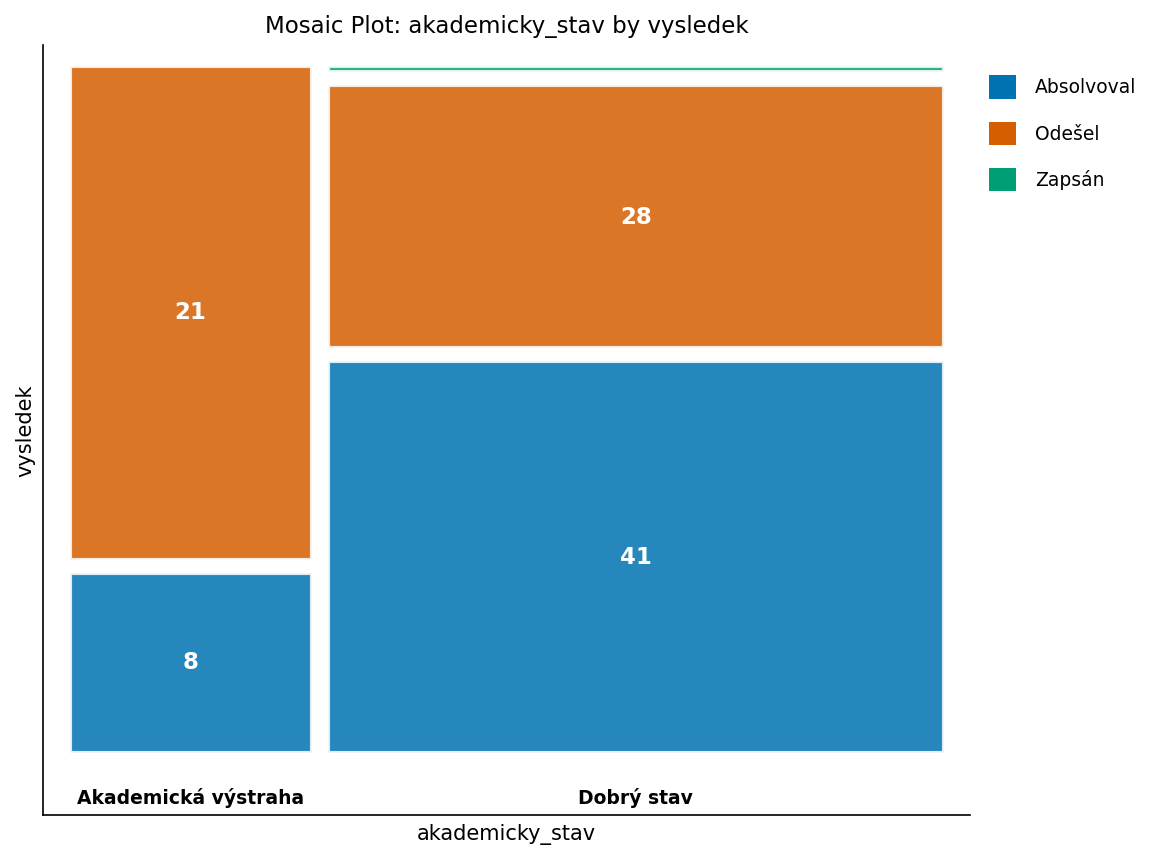

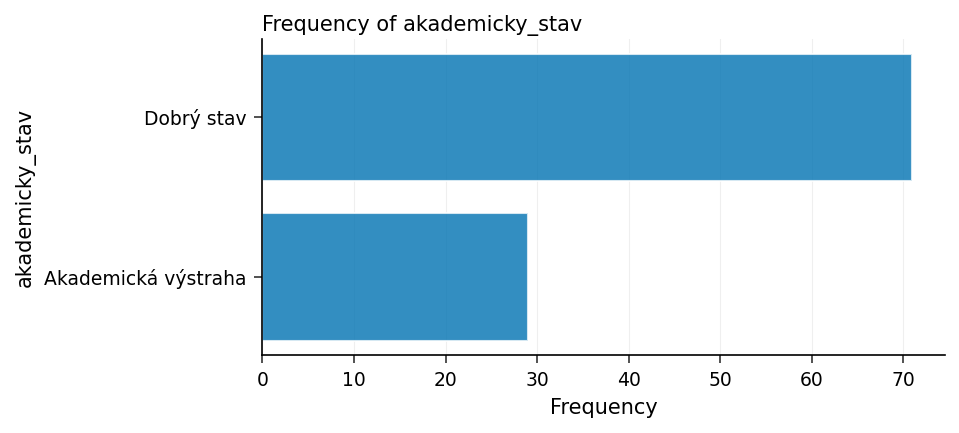

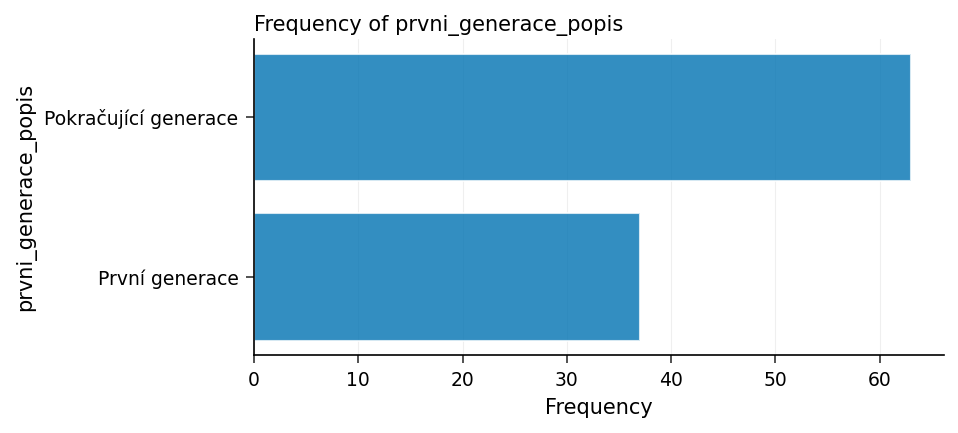

In [3]:
PROCEDURA ČETNOSTI data=zapisy;
    TABLES akademicky_stav*vysledek / chisq norow nocol nopercent;
    TABLES akademicky_stav prvni_generace_popis;
SPUSTIT;


## 4. Kdy k odchodům dochází? Percentily podle stavu

U studentů, kteří skutečně odešli, *kdy* odešli? **PROC UNIVARIATE** (omezená na `odesel = 1`) vykazuje 10., 50. (medián) a 90. percentil doby do odchodu v každé skupině stavu, zapsané do výstupní datové sady, kterou poté vytiskneme. To popisuje rozptyl načasování odchodu bez předpokladu rozdělení.

Mediánový odchod mezi studenty, kteří odešli, nastává kolem semestru **2.4** (studijní varování) oproti **2.6** (dobrý stav) — blízko, protože *podmíněně na odchodu* obě skupiny mají tendenci odejít brzy. Efekt stavu tedy není hlavně o tom, *kdy* k odchodu dojde, ale o tom, *kolik* studentů odejde a jak rychle riziková skupina řídne, což je přesně to, co Kaplan-Meierovy křivky v další sekci zachycují.

In [4]:
PROCEDURA UNIVARIATE data=zapisy NOPRINT;
    KDE odesel = 1;
    TŘÍDA akademicky_stav;
    PROMĚNNÁ cas_semestry;
    VÝSTUP out=ref_odchodu pctlpts=10 50 90 pctlpre=t_ p=;
SPUSTIT;

/* Popisky pro české záhlaví sloupců ve výstupní sadě */
data ref_odchodu;
    NASTAVIT ref_odchodu;
    ŠTÍTEK akademicky_stav = "Akademický stav"
          t_10 = "10. percentil"
          t_50 = "Medián"
          t_90 = "90. percentil";
SPUSTIT;

PROCEDURA TISK data=ref_odchodu noobs ŠTÍTEK;
    NÁZEV "Percentily doby do odchodu (semestry) podle akademického stavu";
SPUSTIT;
NÁZEV;


                             Percentily doby do odchodu (semestry) podle akademického stavu                             

      Akademický stav  10. percentil   Medián  90. percentil
Akademická výstraha              0.2      2.4            7.9
Dobrý stav                       0.4      2.6            8.7




NOTE: PROC UNIVARIATE
NOTE: Output dataset ref_odchodu has 2 observations and 4 variables.
NOTE: DATA ref_odchodu


NOTE: Read 2 rows from ref_odchodu.
NOTE: Wrote ref_odchodu (2 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ref_odchodu

NOTE: PROC PRINT completed: 2 observations printed, 4 variables


## 5. Kaplan-Meierovy křivky odchodu podle studijního stavu

Nyní jádro kroku přežití. **PROC LIFETEST** odhaduje neparametrickou **Kaplan-Meierovu** funkci přežití pro *dobu do odchodu* a zachází s promocí a probíhajícím zápisem jako s cenzurováním (`odesel(0)` označuje cenzurovaná pozorování). Stratifikace podle `akademicky_stav` vytváří jednu křivku odchodu na skupinu a `TEST=(LOGRANK WILCOXON)` provádí dva komplementární testy, zda se tyto křivky liší: **log-rank** test váží všechny časy událostí stejně (citlivý na pozdní rozdíly), zatímco **Wilcoxonův** test více váží rané časy událostí (citlivý na raný úbytek). `PLOTS=SURVIVAL` požaduje překrytou grafiku křivek přežití.

Napříč kohortou je **49 událostí odchodu a 51 cenzurovaných** pozorování. Křivky se jasně oddělují: studenti se studijním varováním dosahují **mediánového přežití (doby do odchodu) 3.8 semestru**, zatímco studenti v dobrém stavu vydrží více než dvakrát déle (**8.7 semestru**). Oba testy zamítají rovnost — **log-rank chí-kvadrát = 10.73, *p* = 0.0011; Wilcoxon chí-kvadrát = 7.66, *p* = 0.0056** — a srovnatelné statistiky nám říkají, že mezera je udržována napříč celým oknem zápisu, nejen ranou špičkou. Graf činí sdělení okamžitým: oranžová křivka studijního varování strmě klesá během prvních čtyř semestrů, zatímco modrá křivka dobrého stavu zůstává vysoko.

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                      100
Event                       49
Censored                    51
Median Survival Time    3.8500

Stratum: Akademický stav = Akademická výstraha

                             N
--------------------  --------
Total                       29
Event                       21
Censored                     8
Median Survival Time    3.8000

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  0.1000    0.9310     0.0471              29                 2
  0.2000    0.8966     0.0566              27                 1
  0.3000    0.8621     0.0640              26                 1
  1.2000    0.8276     0.0701              25                 1
  1.5000    0.7916     0.0758              23                 1
  1.6000    0.7556     0.0804    


NOTE: PROC LIFETEST data=zapisy

NOTE: Using Python lifelines version 0.30.3
NOTE: ODS plot written: survival_strata.spec.json
NOTE: PROC LIFETEST completed.


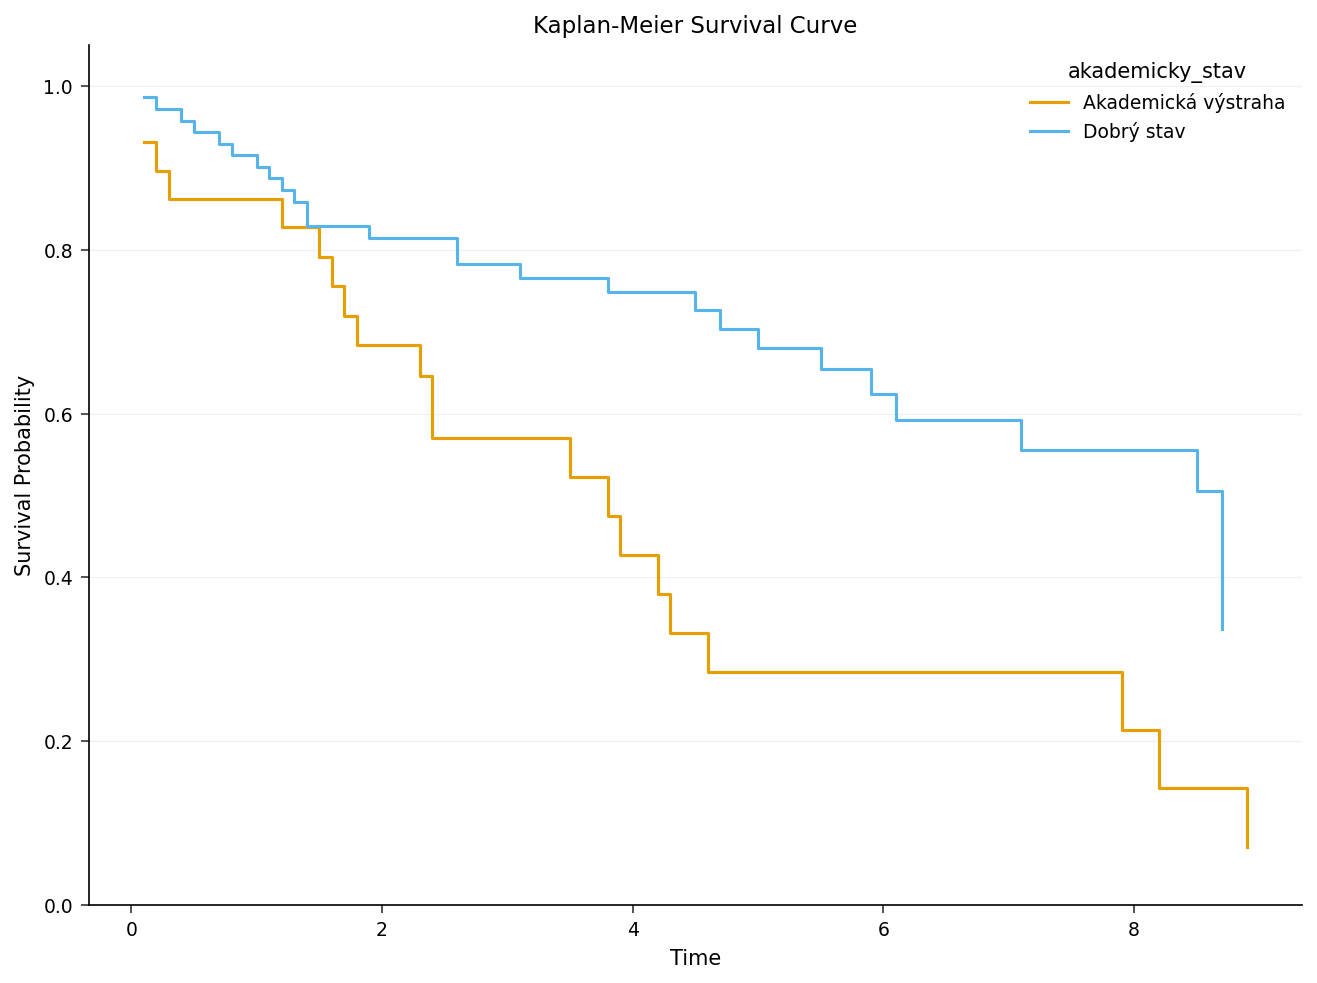

In [5]:
PROCEDURA LIFETEST data=zapisy PLOTS=SURVIVAL METHOD=km;
    TIME cas_semestry*odesel(0);
    STRATA akademicky_stav / TEST=(logrank WILCOXON);
SPUSTIT;


## 6. Vícerozměrný Coxův model proporcionálních rizik pro odchod

**PROC PHREG** fituje **Coxův model proporcionálních rizik** pro riziko odchodu a upravuje prediktory současně. Klíčové požadavky:

- `odesel(0)` činí událostí **odchod** a vše ostatní cenzurovaným.
- `CLASS prvni_generace_popis (ref="Pokračující generace") / param=ref` referenčně kóduje faktor první generace, takže se jeho poměr rizik čte vůči studentům pokračující generace.
- `TIES=EFRON` je doporučená aproximace ošetření shod, když v témž semestru odejde několik studentů.
- `RL` přidává konfidenční intervaly poměru rizik (rizikové meze).
- Příkaz `HAZARDRATIO` vykazuje kontrast první generace vůči referenční skupině.

Poměr rizik nad 1 znamená *rychlejší* odchod (vyšší riziko); pod 1 znamená *pomalejší* odchod (ochranný).

In [6]:
PROCEDURA PHREG data=zapisy;
    TŘÍDA prvni_generace_popis (REF="Pokračující generace") / PARAM=REF;
    MODEL cas_semestry*odesel(0) = ss_prumer prumer_1sem prvni_generace_popis pell
          / TIES=efron rl;
    hazardratio "První generace vs pokračující" prvni_generace_popis / DIFF=REF;
SPUSTIT;


        The PHREG Procedure        

Criterion                     Value
----------------------  -----------
Number of Observations          100
Number of Events                 49
-2 LOG L                    352.536
Ties Handling                 efron
Convergence Status      0 Converged

      Testing Global Null Hypothesis: BETA=0      

Test              Chi-Square        DF  Pr > ChiSq
----------------  ----------  --------  ----------
Likelihood Ratio     31.1053         4      <.0001
Wald                 29.9969         4      <.0001
Score (Log-Rank)     31.2100         4      <.0001

                                                 Analysis of Maximum Likelihood Estimates                                                 

Parameter                                   DF  Estimate  Standard Error  Chi-Square  Pr > ChiSq  Hazard Ratio  95% Lower CL  95% Upper CL
------------------------------------  --------  --------  --------------  ----------  ----------  ------------  -----------


NOTE: PROC PHREG data=zapisy

NOTE: PROC PHREG spec written to: ./ods_output/phreg_basic.spec.json
NOTE: PROC PHREG using Python wrapper


## 7. Interpretace a další kroky

**Čtení výstupu od začátku do konce:**

- **PROC MEANS** potvrzuje simulovaný signál: studenti, kteří promovali, nesou vyšší GPA prvního semestru (2.94 vs 2.54) a středoškolské GPA (3.10 vs 2.90) než studenti, kteří odešli, a stále zapsaní studenti sedí na stropě 12 semestrů — cenzurování zprava, které modely přežití respektují.
- **PROC FREQ** ukazuje, že příznak studijního varování v prvním semestru sleduje výsledek (21 z 29 označených studentů odešlo; 41 z 71 studentů v dobrém stavu promovalo; *p* = 0.0100), přičemž poctivě upozorňuje, že chí-kvadrát je křehký v tabulce se 100 studenty a řídkými buňkami.
- **PROC UNIVARIATE** ukazuje, že *podmíněně na odchodu* obě skupiny odcházejí brzy (medián ~2.4–2.6 semestru); efekt stavu je o tom, kolik studentů odejde a jak rychle riziková skupina řídne, nikoli o načasování mezi těmi, kdo odcházejí.
- **PROC LIFETEST** přináší titulní zprávu: Kaplan-Meierovy křivky odchodu, které se ostře oddělují podle stavu (medián 3.8 vs 8.7 semestru; log-rank *p* = 0.0011, Wilcoxon *p* = 0.0056). Příznak včasného varování je skutečný, statisticky podložený diskriminátor načasování odchodu.
- **PROC PHREG** kvantifikuje upravený efekt každého prediktoru na riziko odchodu. Po úpravě je **GPA prvního semestru nejsilnějším ochranným faktorem** (poměr rizik 0.21 na bod GPA, 95% CI 0.10–0.44, *p* < 0.0001): každý další bod GPA snižuje riziko odchodu zhruba o čtyři pětiny. **Středoškolské GPA** je také ochranné (HR 0.45, 95% CI 0.22–0.91, *p* = 0.027). **Studenti první generace** čelí zhruba dvojnásobnému riziku odchodu než jejich vrstevníci z pokračující generace se stejným GPA (HR 2.03, 95% CI 1.07–3.84, *p* = 0.031). **Status Pell není významný**, jakmile je GPA zohledněno (HR 0.95, 95% CI 0.53–1.69, *p* = 0.85) — užitečná připomínka, že surový rizikový faktor se může po úpravě vytratit. Globální nulová hypotéza je rozhodně zamítnuta (chí-kvadrát věrohodnostního poměru = 31.11 na 4 df, *p* < 0.0001).

**Jak by na to instituce reagovala.** Coxův model vytváří lineární prediktor na studenta (rizikové skóre), které řadí kohortu podle rizika odchodu; studenti s nejvyšším rizikem — nízké GPA prvního semestru v kombinaci se statusem první generace — jsou směrováni k poradenství včasného varování v prvních semestrech, kdy je intervence nejlevnější a nejúčinnější. Kaplan-Meierovo porovnání dává poradcům jediné, obhajitelné kritérium, které již na konci prvního semestru sbírají: studijní stav.

**Výhrady a rozšíření.** (1) Tato syntetická kohorta zachází s promocí jako s cenzurováním pro model odchodu; u reálných dat jsou promoce a odchod skutečnými **konkurenčními riziky** a rozšíření pro konkurenční rizika (kumulativní incidence) přes PROC PHREG `EVENTCODE=` by zabránilo nadhodnocení pravděpodobnosti odchodu. (2) Předpoklad proporcionálních rizik by měl být ověřen (PHREG `ASSESS PH` nebo Schoenfeldova rezidua) dříve, než se spolehneme na jediný poměr rizik napříč všemi semestry. (3) Časově proměnné kovariáty — GPA semestr po semestru, změny finanční pomoci, studijní zátěž — jsou v datech o udržení běžné a jsou přirozeně zpracovány oborovými příkazy PHREG. (4) Kohorta 100 studentů zde je dimenzována na strop běhu bez licence; produkční analýza by nesla několik tisíc studentů, čímž by zúžila každý konfidenční interval. Vždy ověřte nasazené rizikové skóre na vyčleněné kohortě, než na jeho základě začnete operativně jednat.